In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'


In [32]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [33]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [34]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [35]:
df = df.sort_values('datetime').reset_index(drop=True)


In [36]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station', 'aqi']]

In [37]:
df

,year,month,day,hour,is_weekend,season,station,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",500
3,2020,1,1,6,0,winter,Noida Sec 125,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",473
...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,500
201660,2025,12,31,23,0,winter,Noida Sec 125,489
201661,2025,12,31,23,0,winter,Greater Noida,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",500


In [38]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [39]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,aqi
2,2020,1,1,6,0,winter,500
25,2020,1,1,12,0,winter,408
67,2020,1,1,18,0,winter,466
70,2020,1,1,23,0,winter,500
98,2020,1,2,6,0,winter,500
...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,500
201578,2025,12,31,6,0,winter,500
201597,2025,12,31,12,0,winter,349
201627,2025,12,31,18,0,winter,426


In [40]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [41]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [42]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,500,False,False,True
25,2020,1,1,12,0,408,False,False,True
67,2020,1,1,18,0,466,False,False,True
70,2020,1,1,23,0,500,False,False,True
98,2020,1,2,6,0,500,False,False,True
...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,500,False,False,True
201578,2025,12,31,6,0,500,False,False,True
201597,2025,12,31,12,0,349,False,False,True
201627,2025,12,31,18,0,426,False,False,True


In [43]:
df.isna().sum()

year          0
month         0
day           0
hour          0
is_weekend    0
season        0
station       0
aqi           0
dtype: int64

In [44]:
df1 = df1.dropna().reset_index(drop=True)


In [45]:
df1 = df1.dropna().reset_index(drop=True)


In [46]:
X=df1.drop(columns=["aqi"])
Y=df1["aqi"]
X

,year,month,day,hour,is_weekend,season_post_monsoon,season_summer,season_winter
0,2020,1,1,6,0,False,False,True
1,2020,1,1,12,0,False,False,True
2,2020,1,1,18,0,False,False,True
3,2020,1,1,23,0,False,False,True
4,2020,1,2,6,0,False,False,True
...,...,...,...,...,...,...,...,...
8763,2025,12,30,23,0,False,False,True
8764,2025,12,31,6,0,False,False,True
8765,2025,12,31,12,0,False,False,True
8766,2025,12,31,18,0,False,False,True


In [47]:
Y

0       500
1       408
2       466
3       500
4       500
       ... 
8763    500
8764    500
8765    349
8766    426
8767    500
Name: aqi, Length: 8768, dtype: int64

In [48]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

X_train = train_df.drop(columns=['aqi'])
Y_train = train_df['aqi']

X_test = test_df.drop(columns=['aqi'])
Y_test = test_df['aqi']


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [50]:
ann = Sequential()

ann.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann.add(Dense(16, activation='relu'))
ann.add(Dense(1))  # single output for regression




ann.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=50),
    metrics=['mae']
)
ann.summary()

C:\Users\Dhruv\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

from tensorflow.keras.callbacks import Callback

class StopOnRecentImprovement(Callback):
    def __init__(self, window=8, min_improvement=0.003):
        super().__init__()
        self.window = window
        self.min_improvement = min_improvement
        self.mae_history = []
        self.best_mae = float('inf')
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        mae = logs.get('mae')
        if mae is None:
            return

        # save best weights
        if mae < self.best_mae:
            self.best_mae = mae
            self.best_weights = self.model.get_weights()

        self.mae_history.append(mae)

        # check recent improvement
        if len(self.mae_history) > self.window:
            recent = self.mae_history[-(self.window+1):]
            improvement = recent[0] - recent[-1]

            if improvement < self.min_improvement:
                print(
                    f"\nStopping training: mae improved only "
                    f"{improvement:.4f} in last {self.window} epochs"
                )
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        # restore best weights
        if self.best_weights is not None:
            print(f"Restoring best weights (best mae: {self.best_mae:.4f})")
            self.model.set_weights(self.best_weights)


In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=8,
    min_delta=0.08,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=5,
    min_delta=0.08,
    min_lr=1e-5,
    verbose=1
)


history = ann.fit(
    X_train_scaled,
    Y_train,
    epochs=250,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],   # LR should act first
    verbose=1
)


Epoch 1/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 10985.4482 - mae: 244.4601 - val_loss: 10465.6934 - val_mae: 233.8408 - learning_rate: 0.0010
Epoch 2/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10071.9893 - mae: 225.1873 - val_loss: 8799.6836 - val_mae: 198.1824 - learning_rate: 0.0010
Epoch 3/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7691.0430 - mae: 175.6262 - val_loss: 6682.3818 - val_mae: 154.8818 - learning_rate: 0.0010
Epoch 4/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5801.6919 - mae: 138.4117 - val_loss: 5201.4272 - val_mae: 125.5560 - learning_rate: 0.0010
Epoch 5/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4283.2407 - mae: 108.3844 - val_loss: 3685.3354 - val_mae: 94.8767 - learning_rate: 0.0010
Epoch 6/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3171.5105 - mae: 85.4641 - val_loss: 2748.1133 - val_mae: 75.6921 - learning_rate: 0.0010
Epoch 7/250
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2381.1746 - mae: 69.4

In [59]:
Y_pred_ann = ann.predict(X_test_scaled).flatten()


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [60]:
print(len(history.history['loss']))


250


In [61]:
import numpy as np

best_epoch = np.argmin(history.history['val_mae']) + 1
best_val_mae = np.min(history.history['val_mae'])

print("Best epoch:", best_epoch)
print("Best val_mae:", best_val_mae)


Best epoch: 248
Best val_mae: 24.480209350585938


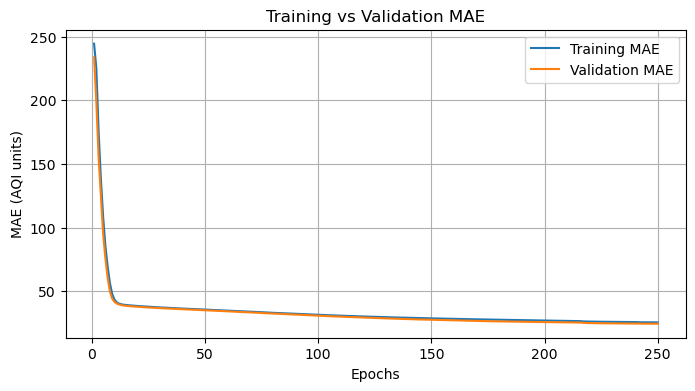

In [62]:
epochs = range(1, len(history.history['mae']) + 1)

plt.figure(figsize=(8, 4))

plt.plot(epochs, history.history['mae'], label='Training MAE')
plt.plot(epochs, history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('MAE (AQI units)')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()


In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = ann.predict(X_test_scaled).flatten()

mae  = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))

print("ANN MAE :", mae)
print("ANN RMSE:", rmse)
from sklearn.metrics import r2_score
r2= r2_score(Y_test, y_pred)
print("ANN R2:", r2)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
ANN MAE : 26.871007919311523
ANN RMSE: 34.40884342519195
ANN R2: 0.9583679437637329


In [57]:
Y_pred_ann = ann.predict(X_test_scaled).flatten()


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


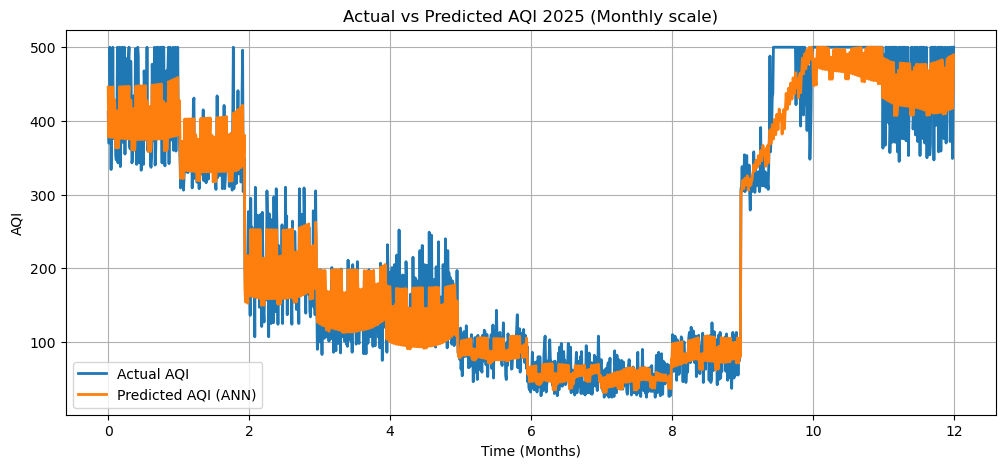

In [58]:
import numpy as np
import matplotlib.pyplot as plt
Y_pred_ann = np.clip(Y_pred_ann, 0, 500)

# Number of samples
n_samples = len(Y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.figure(figsize=(12, 5))

plt.plot(x_months, Y_test.values,
         label='Actual AQI', linewidth=2)

plt.plot(x_months, Y_pred_ann,
         label='Predicted AQI (ANN)', linewidth=2)

plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI 2025 (Monthly scale)')
plt.legend()
plt.grid(True)
plt.savefig("ann_training_validation_mae2.jpg", dpi=300, bbox_inches="tight")
plt.show()
